In [1]:
from pathlib import Path
import os
import sys

# Make repo imports work even when the kernel starts inside a notebook subdirectory.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / 'configs' / 'profiles.py').exists():
    _repo_root = _repo_root.parent
if not (_repo_root / 'configs' / 'profiles.py').exists():
    raise RuntimeError("Failed to locate MADRL_ESS repo root containing configs/profiles.py.")
_repo_root_str = str(_repo_root)
if _repo_root_str not in sys.path:
    sys.path.insert(0, _repo_root_str)
os.chdir(_repo_root)


# Local MPC

直接按 canonical 3-agent 配置生成 perfect / LSTM 两条本地 MPC 测试结果，并写入 `notebooks/record/mpc/`。

In [2]:

from pprint import pprint

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from configs.profiles import compose_experiment_config, project_root, summarize_experiment
from predictors.mainline_forecast import get_mainline_forecast_controls
from scripts.mainline_compare import (
    LOCAL_MPC_LSTM_LABEL,
    LOCAL_MPC_PERFECT_LABEL,
    collect_local_mpc_rollout,
    compare_rollout_metrics,
)
from scripts.utils.grid_notebook_workflow import (
    COMPARISON_WINDOW_CONTRACT,
    apply_notebook_experiment_settings,
    bootstrap_madrl_notebook_shared_data,
    build_comparison_cfg,
    plot_battery_power_and_soc_comparison,
    plot_net_load_comparison,
    plot_power_balance_comparison,
    plot_price_prediction_comparison,
    plot_voltage_profile_comparison,
    resolve_comparison_episode_window,
    resolve_episode_indices_for_start_timestamps,
    save_rollout_record,
)
from scripts.utils.torch_runtime import configure_torch_runtime


In [3]:

root = project_root()
cfg = compose_experiment_config(
    forecast_type='lstm',
    data_dir=root / 'data',
    runtime_mode='performance',
    seed=0,
)
forecast_controls = get_mainline_forecast_controls(auto_train_missing=False)
apply_notebook_experiment_settings(
    cfg,
    prediction_mode='normal',
    test_start_date=None,
    test_end_date=None,
    agent_profiles=None,
    agent_bus_ids=None,
    load_scale=None,
    pv_scale=None,
    future_horizon=int(forecast_controls['future_horizon']),
    battery_controls=None,
    forecast_controls=forecast_controls,
    train_year=None,
    test_year=None,
)
cfg.forecast.auto_train_missing = False
bootstrap_madrl_notebook_shared_data(cfg, root=root, notebook_path='notebooks/madrl/local_MPC.ipynb')
runtime_state = configure_torch_runtime(cfg, seed=cfg.runtime.seed)
cfg.runtime.device = runtime_state.device

comparison_window = resolve_comparison_episode_window(cfg)
episode_start_timestamps = list(comparison_window['episode_start_timestamps'])
perfect_cfg = build_comparison_cfg(cfg, prediction_mode='perfect')
perfect_cfg.data.test_start_date = None
perfect_cfg.data.test_end_date = None
perfect_episode_indices = resolve_episode_indices_for_start_timestamps(perfect_cfg, episode_start_timestamps)
lstm_episode_indices = resolve_episode_indices_for_start_timestamps(cfg, episode_start_timestamps)
local_mpc_perfect = collect_local_mpc_rollout(
    perfect_cfg,
    prediction_mode='perfect',
    label=LOCAL_MPC_PERFECT_LABEL,
    episode_indices=perfect_episode_indices,
    show_progress=True,
)
local_mpc_lstm = collect_local_mpc_rollout(
    cfg,
    prediction_mode='normal',
    label=LOCAL_MPC_LSTM_LABEL,
    episode_indices=lstm_episode_indices,
    show_progress=True,
)
perfect_window_meta = {'comparison_window_contract': COMPARISON_WINDOW_CONTRACT, 'episode_start_timestamps': episode_start_timestamps, 'backend_episode_indices': perfect_episode_indices}
lstm_window_meta = {'comparison_window_contract': COMPARISON_WINDOW_CONTRACT, 'episode_start_timestamps': episode_start_timestamps, 'backend_episode_indices': lstm_episode_indices}
save_rollout_record(local_mpc_perfect, category='mpc', scheme_name='local_mpc_perfect', root=root, config_snapshot={'cfg_summary': summarize_experiment(cfg), 'solve_cfg_summary': summarize_experiment(perfect_cfg), 'prediction_mode': 'perfect', **perfect_window_meta}, extra_meta=perfect_window_meta)
save_rollout_record(local_mpc_lstm, category='mpc', scheme_name='local_mpc_lstm', root=root, config_snapshot={'cfg_summary': summarize_experiment(cfg), 'prediction_mode': 'normal', **lstm_window_meta}, extra_meta=lstm_window_meta)
metrics_df = compare_rollout_metrics(local_mpc_perfect, local_mpc_lstm)
display(metrics_df)
pprint({'record_root': str(root / 'notebooks' / 'record' / 'mpc')})


c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2685996
Academic license 2685996 - for non-commercial use only - registered to 20___@mail.scut.edu.cn


,controller,soc_mode,purchase_cost_total,purchase_cost_total_eur,export_subsidy_total,export_subsidy_total_eur,total_cost_eur,objective_total,soc_penalty_total,voltage_penalty_total,...,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur,purchase_cost_sfh12,purchase_cost_sfh18,purchase_cost_sfh20
0,Local MPC + Perfect Forecast,reset,521.38295,521.38295,0.0,0.0,521.38295,521.38295,0.0,0.0,...,0.051633,0,57.589169,10.03360,145.523849,8.011493,NaN,208.502710,137.053261,175.826979
1,Local MPC + LSTM Forecast,reset,571.41405,571.41405,0.0,0.0,571.41405,571.41405,0.0,0.0,...,0.063260,0,69.276039,11.50391,150.603943,7.247048,NaN,223.222448,165.595294,182.596308


{'record_root': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\notebooks\\record\\mpc'}


1. 电力电量平衡


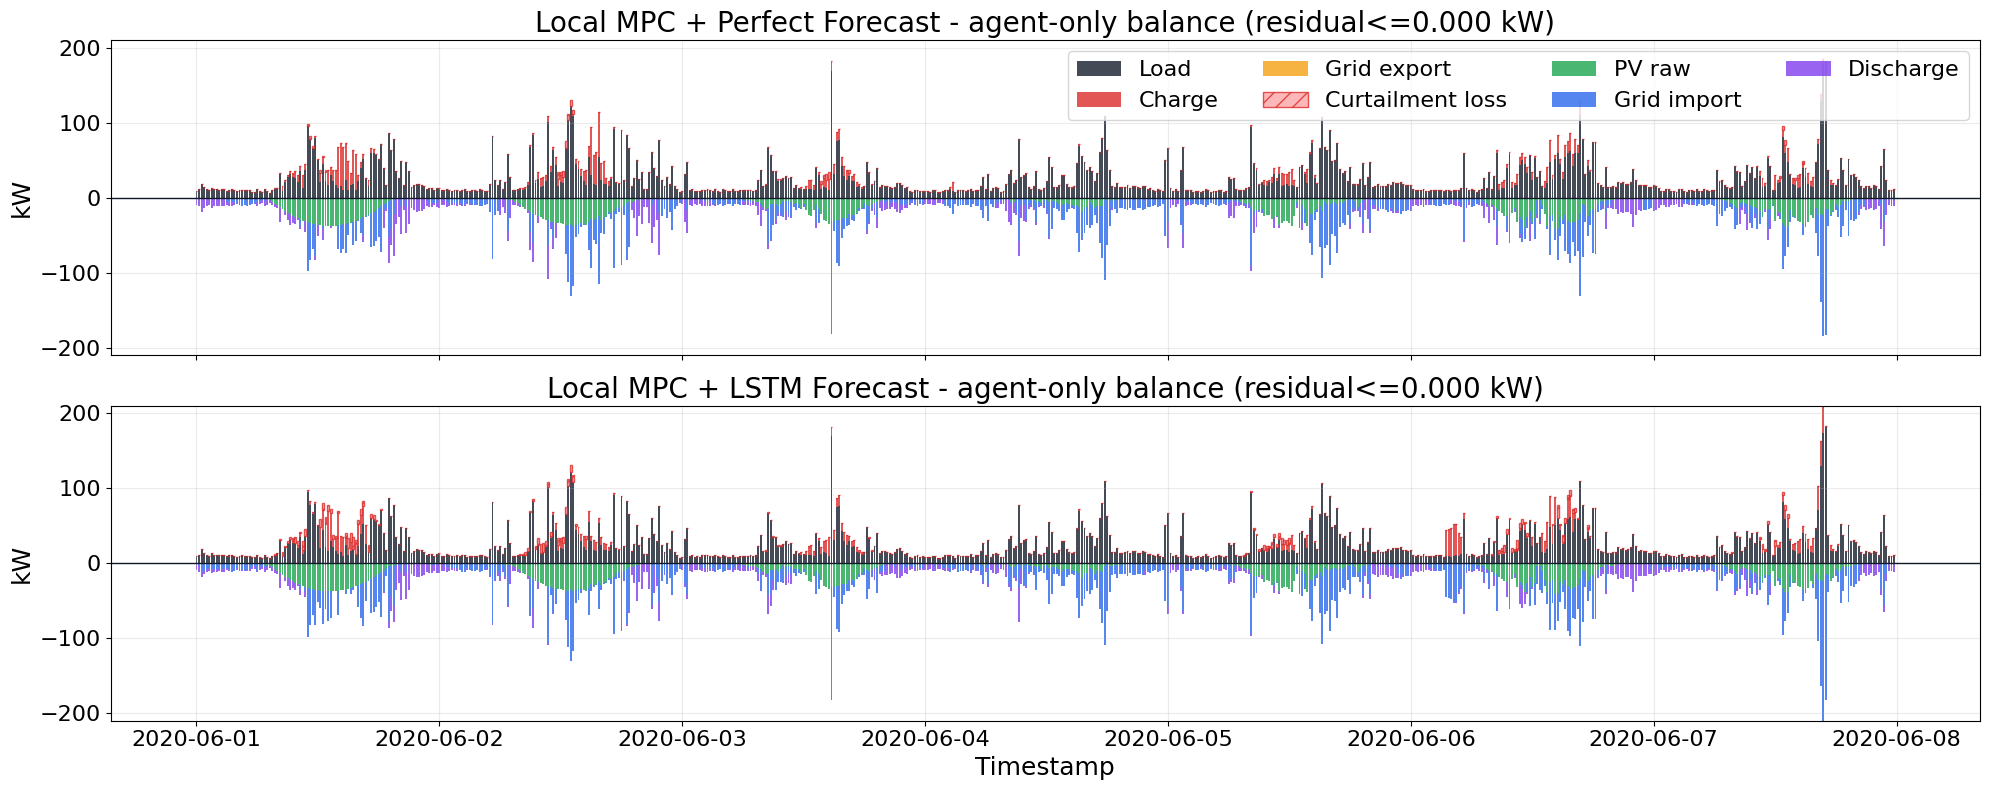

2. 电价


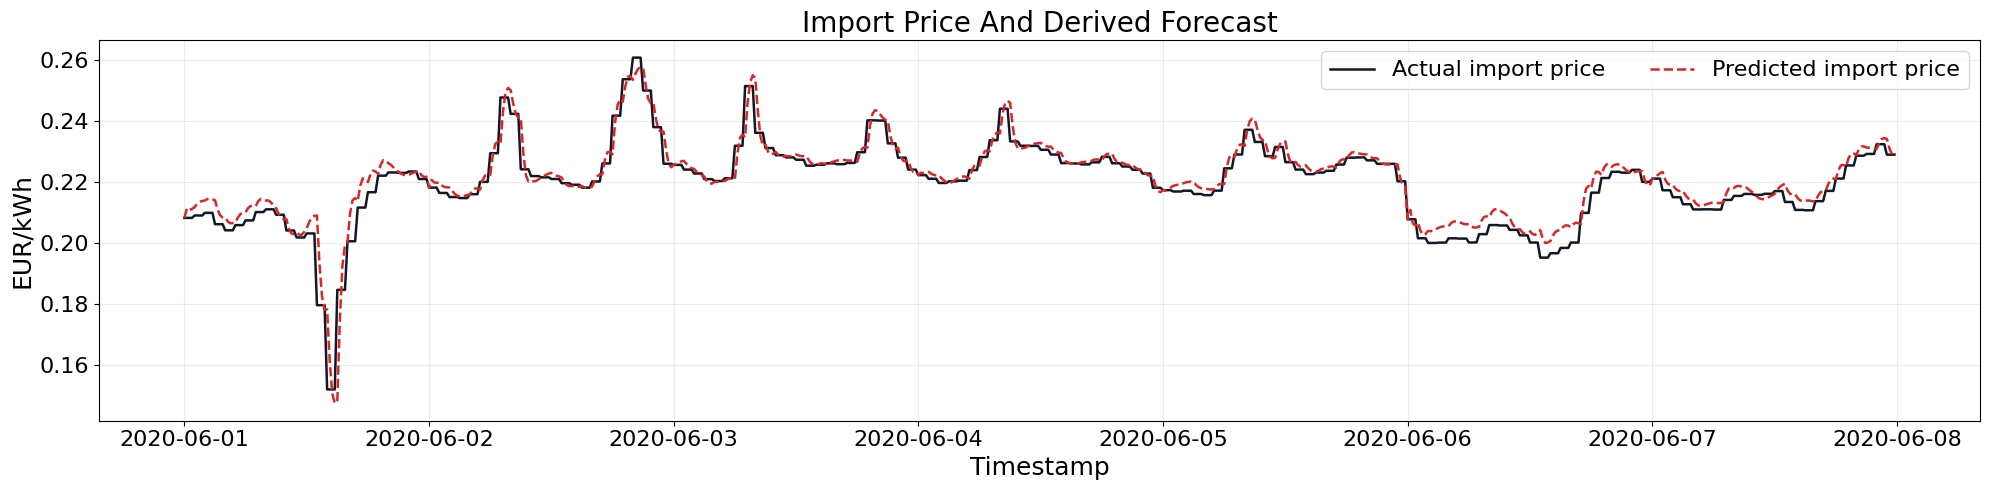

3. 总体储能充放功率与 SoC


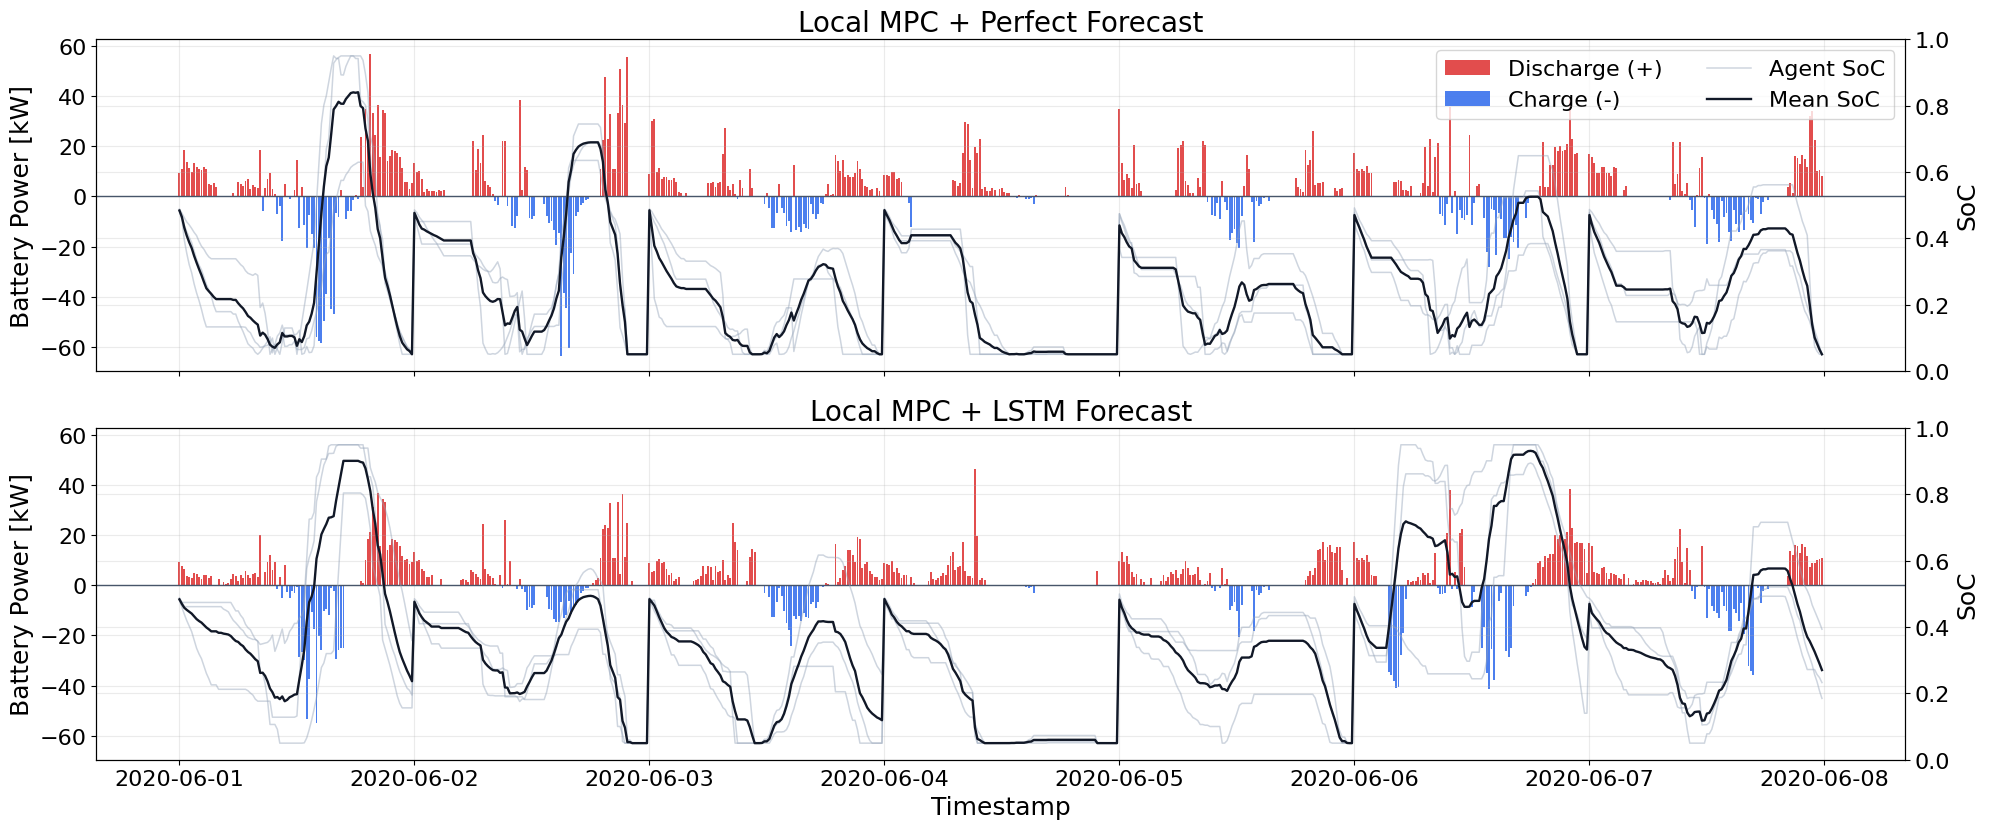

4. 电压


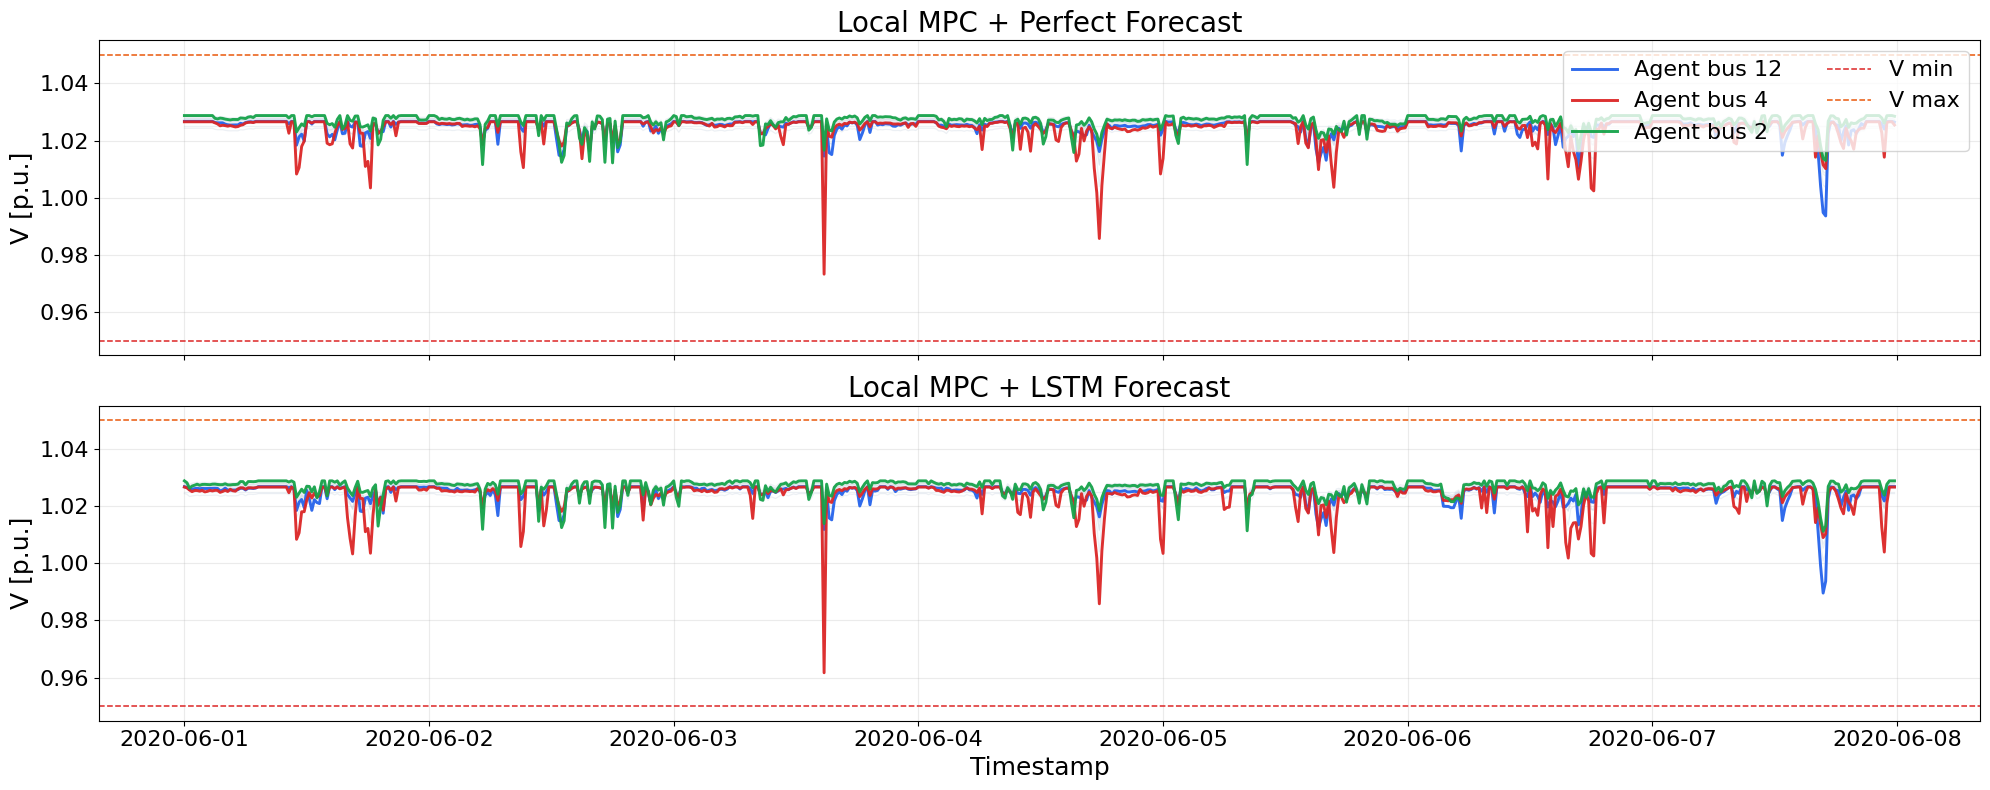

5. 净负荷


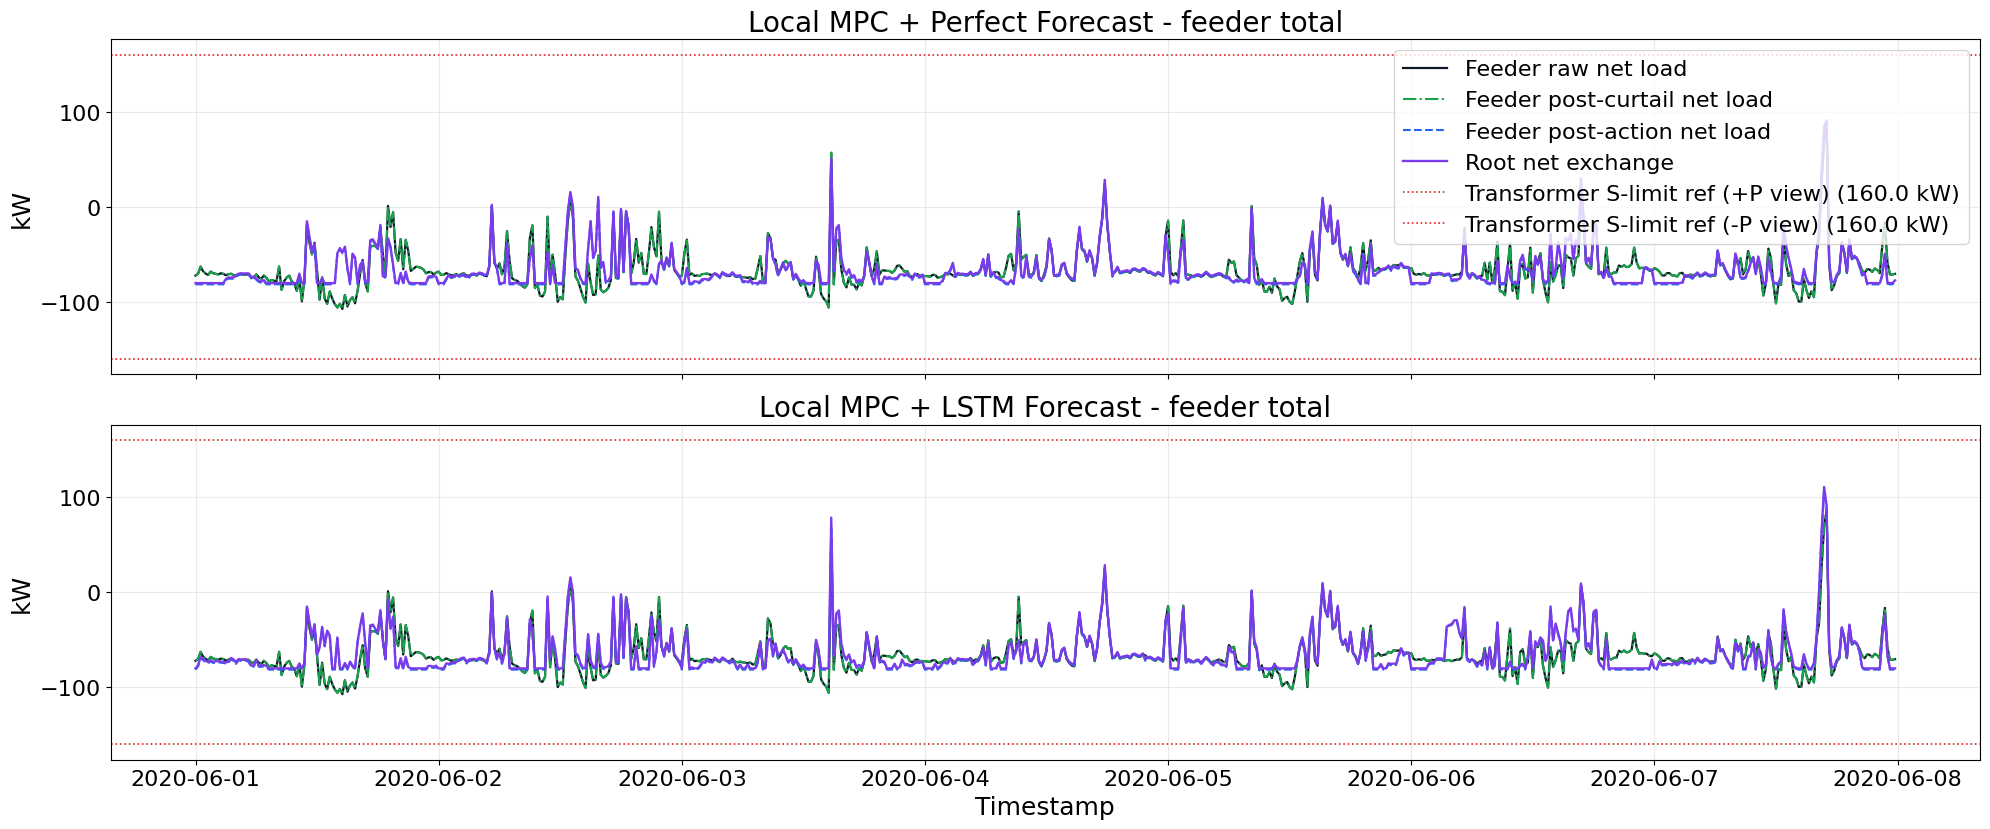

In [4]:
# 统一展示 Local MPC 的关键对比图，直接对照 perfect 与 lstm 两条 rollout。
_plot_specs = [
    ('1. 电力电量平衡', plot_power_balance_comparison),
    ('2. 电价', plot_price_prediction_comparison),
    ('3. 总体储能充放功率与 SoC', plot_battery_power_and_soc_comparison),
    ('4. 电压', plot_voltage_profile_comparison),
    ('5. 净负荷', plot_net_load_comparison),
]

for title, plot_fn in _plot_specs:
    print(title)
    figure = plot_fn(local_mpc_perfect, local_mpc_lstm)
    display(figure)
    plt.close(figure)
